In [30]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

In [31]:
df= pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [ ]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


**Part 1**: Understanding Product Categories

Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

**Frequency Tables**:

Generate a frequency table for the product category.
Which are the top 5 most listed product categories?

**Visualizations**:

Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.

For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

1.1 Frequency Tables & Top 5 Categories

In [ ]:
#Generate full frequency table
category_frequency = df['category'].value_counts()
print ("Full Category Frequency Table: ")
print (category_frequency)


#Extract the top 5 most listed product categories
top_5_categories = category_frequency.head(5)
print("\nTop 5 Most Listed Categories: " )
print (top_5_categories)


Full Category Frequency Table: 
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

Top 5 Most Listed Categories: 
category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


1.2 Popularity by Recent Sales (boughtInLastMonth)

In [ ]:
#Calculate total items bought last month per category

recent_demand = df.groupby('category')['boughtInlastMonth'].sum().sort_values(ascending=False)

2. Bar Chart Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_27777/2326959734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_categories.values, y=top_5_categories.index, palette='viridis')


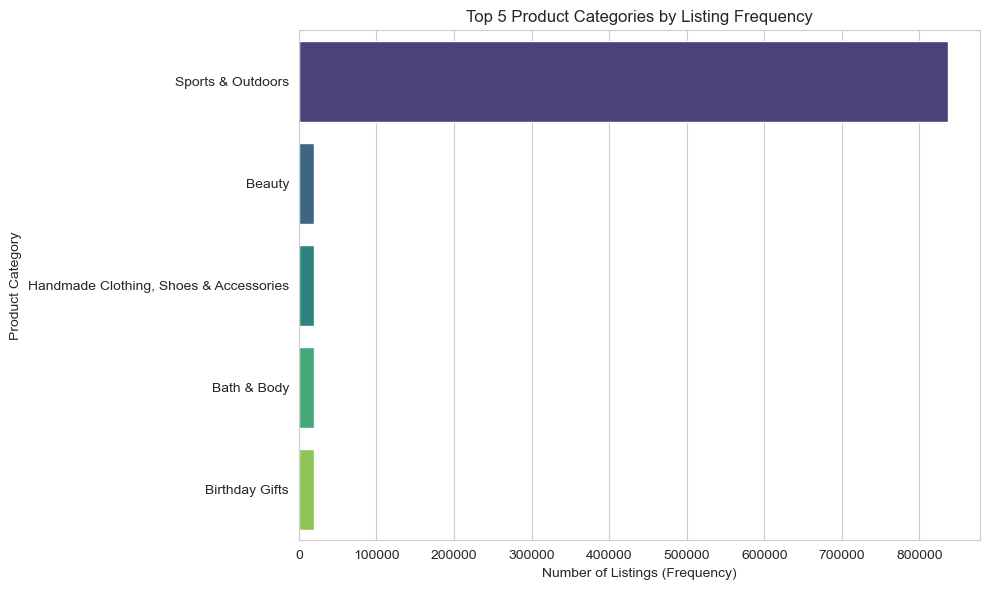

In [ ]:
plt.figure(figsize=(10, 6))

#Get the top 15 categories (this defaults to descending order)
top_5_categories = df['category'].value_counts().head(5)

#Create the horizontal barplot
sns.barplot(x=top_5_categories.values, y=top_5_categories.index, palette='viridis')

plt.title('Top 5 Product Categories by Listing Frequency')
plt.xlabel('Number of Listings (Frequency)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

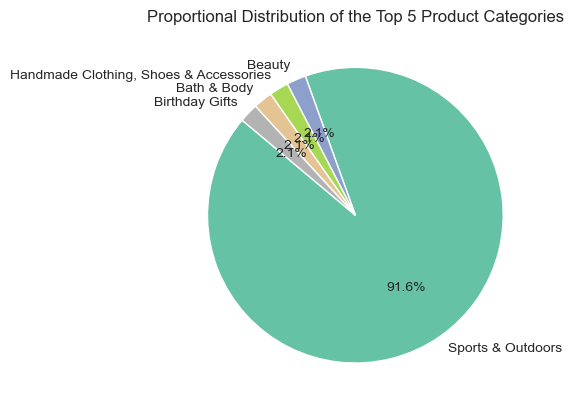

In [ ]:
top_5_categories.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set2')

plt.title('Proportional Distribution of the Top 5 Product Categories')
plt.ylabel('') # Removing the default y-label for a cleaner look
plt.show()

Part 2: Delving into Product Pricing
Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

**Measures of Centrality:**

**Calculate the mean, median, and mode for the price of products.**
What's the average price point of products listed? How does this compare with the most common price point (mode)?
Measures of Dispersion:

**Determine the variance, standard deviation, range, and interquartile range for product price.**
How varied are the product prices? Are there any indicators of a significant spread in prices?

**Visualizations:**

Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

--- Measures of Centrality ---
Mean (Average) Price: £89.24
Median Price: £19.09
Mode (Most Common) Price: £9.99

--- Measures of Dispersion ---
Variance: 119445.49
Standard Deviation: £345.61
Range: £100000.00 (Min: £0.0, Max: £100000.0)
Interquartile Range (IQR): £36.00



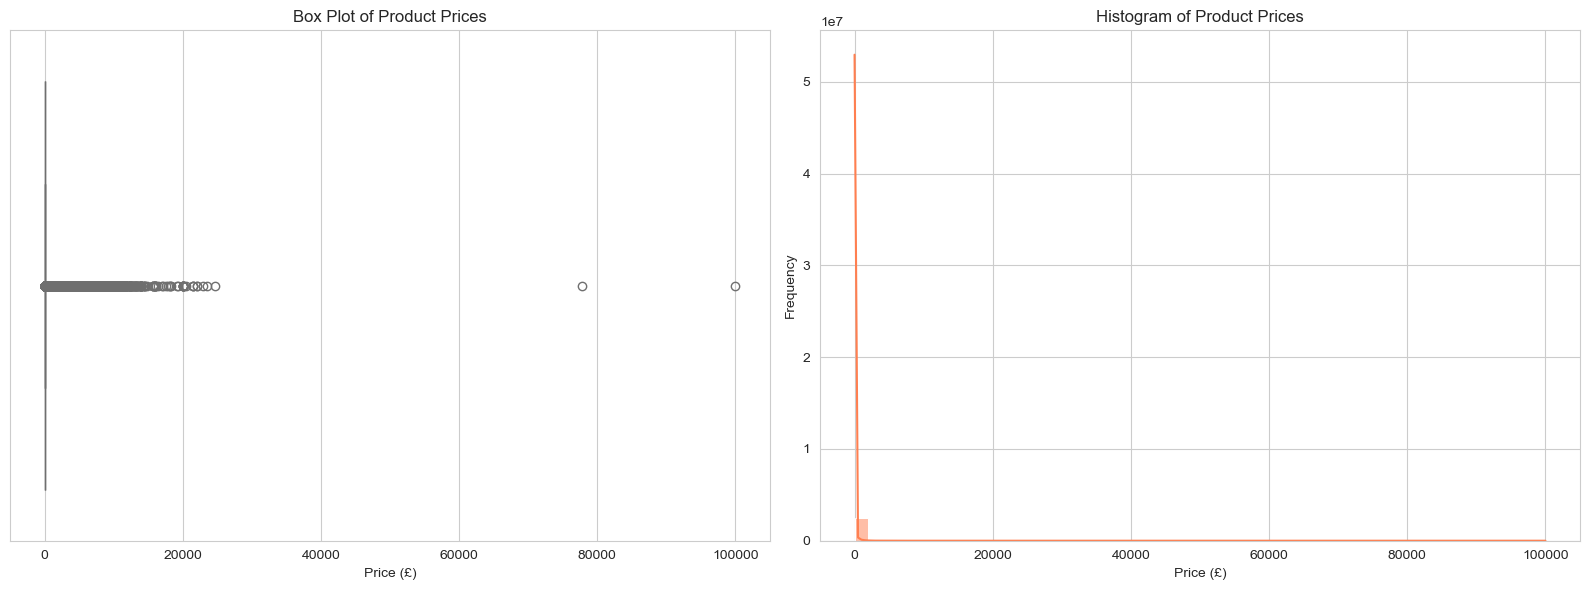

In [ ]:

# --- 1. Measures of Centrality ---
mean_price = df['price'].mean()
median_price = df['price'].median()
# mode() returns a Series, so we take the first value [0] in case of multiple modes
mode_price = df['price'].mode()[0] 

print("--- Measures of Centrality ---")
print(f"Mean (Average) Price: £{mean_price:.2f}")
print(f"Median Price: £{median_price:.2f}")
print(f"Mode (Most Common) Price: £{mode_price:.2f}\n")

# --- 2. Measures of Dispersion ---
variance_price = df['price'].var()
std_price = df['price'].std()
range_price = df['price'].max() - df['price'].min()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
iqr_price = Q3 - Q1

print("--- Measures of Dispersion ---")
print(f"Variance: {variance_price:.2f}")
print(f"Standard Deviation: £{std_price:.2f}")
print(f"Range: £{range_price:.2f} (Min: £{df['price'].min()}, Max: £{df['price'].max()})")
print(f"Interquartile Range (IQR): £{iqr_price:.2f}\n")

#--- 3. Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box Plot
sns.boxplot(x=df['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Box Plot of Product Prices')
axes[0].set_xlabel('Price (£)')

# Histogram
sns.histplot(df['price'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Histogram of Product Prices')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Frequency')
#
plt.tight_layout()
plt.show()

The problem: the data is heavily right-skewed.Because there are hundreds of thousands of items pricend under£50.The histogram has a massike spike on the far left, followed by a long tail stretching to the right. 

We will make adjustments in the plotting to facilitate the visibility (trim the axis (to exclude the outliers)and a logarithmic transformation)

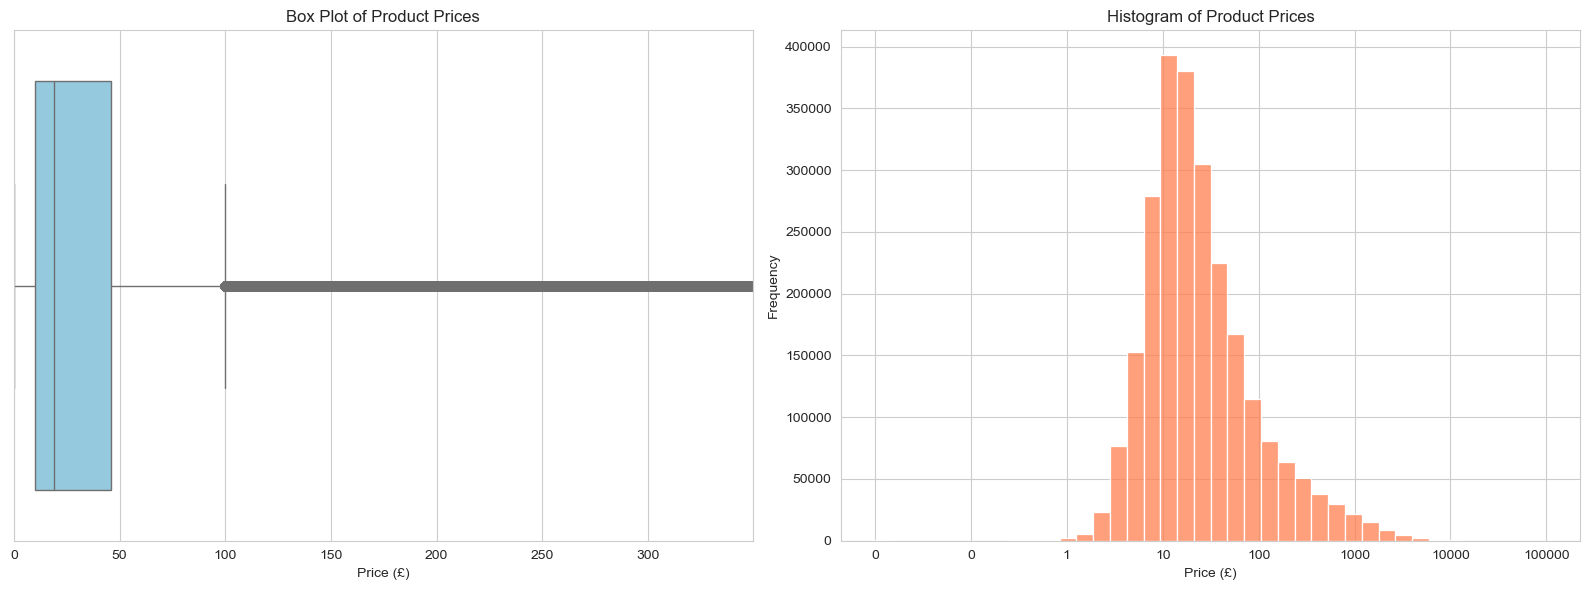

In [ ]:
import matplotlib.ticker as ticker

# --- 4. Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p95 = df['price'].quantile(0.95)
# Box Plot
sns.boxplot(x=df['price'], ax=axes[0], color='skyblue')
axes[0].set_xlim(0,p95)
axes[0].set_title('Box Plot of Product Prices')
axes[0].set_xlabel('Price (£)')

# Histogram
sns.histplot(df['price'], bins=40, kde=False, ax=axes[1], color='coral', log_scale = True)
axes[1].set_title('Histogram of Product Prices')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Frequency')

axes[1].xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()
plt.show()

Part 3: Unpacking Product Ratings
Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

Measures of Centrality:

Calculate the mean, median, and mode for the rating of products.
How do customers generally rate products? Is there a common trend?
Measures of Dispersion:

Determine the variance, standard deviation, and interquartile range for product rating.
Are the ratings consistent, or is there a wide variation in customer feedback?
Shape of the Distribution:

Calculate the skewness and kurtosis for the rating column.
Are the ratings normally distributed, or do they lean towards higher or lower values?
Visualizations:

Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


In [36]:
# --- 1. Measures of Centrality ---
rated_products = df[df['stars'] > 0]

mean_rating = rated_products['stars'].mean()
median_rating = rated_products['stars'].median()
# mode() returns a Series, so we take the first value [0] in case of multiple modes
mode_rating = rated_products['stars'].mode()[0] 

print("--- Measures of Centrality ---")
print(f"Mean (Average) Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating:.2f}")
print(f"Mode (Most Common) Rating: {mode_rating:.2f}\n")


--- Measures of Centrality ---
Mean (Average) Rating: 4.32
Median Rating: 4.40
Mode (Most Common) Rating: 4.50



In [39]:
# --- 2. Measures of Dispersion ---
variance_ratings =rated_products['stars'].var()
std_ratings = rated_products['stars'].std()
range_ratings = rated_products['stars'].max() - df['stars'].min()

Q1_stars = rated_products['stars'].quantile(0.25)
Q3_stars = rated_products['stars'].quantile(0.75)
iqr_stars = Q3_stars - Q1_stars

print("--- Measures of Dispersion ---")
print(f"Variance: {variance_ratings:.2f}")
print(f"Standard Deviation: {std_ratings:.2f}")
print(f"Range: {range_ratings:.2f} (Min: {rated_products['stars'].min()}, Max: {df['stars'].max()})")
print(f"Interquartile Range (IQR): £{iqr_stars:.2f}\n")


--- Measures of Dispersion ---
Variance: 0.31
Standard Deviation: 0.56
Range: 5.00 (Min: 1.0, Max: 5.0)
Interquartile Range (IQR): £0.50



--- Shape of the Distribution (Rated Products Only) ---
Skewness: -2.38
Kurtosis: 9.78



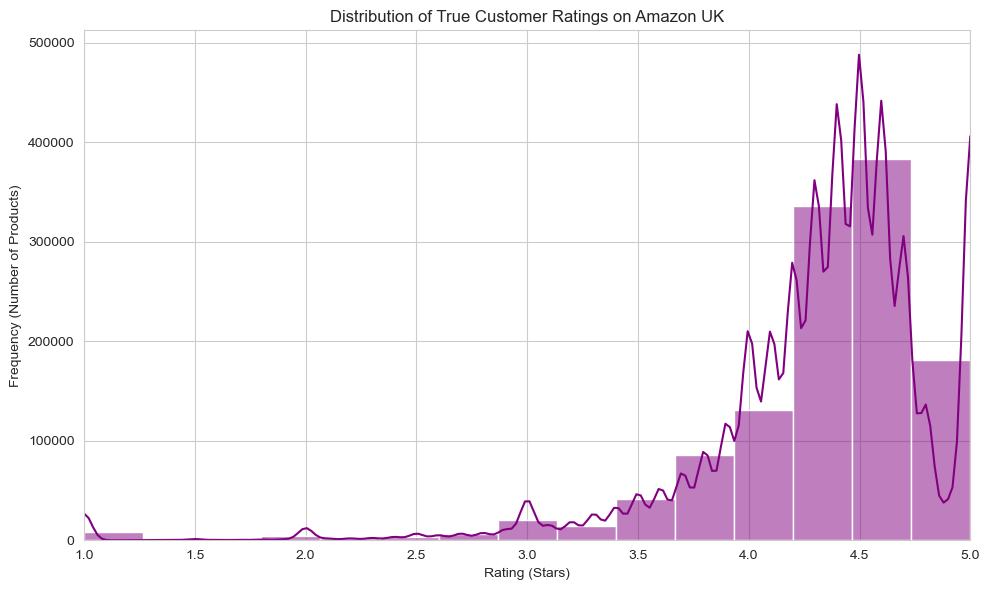

In [40]:
# We are using the filtered data from the previous step:
# rated_products = df[df['stars'] > 0]

# --- Shape of the Distribution (Cleaned Data) ---
skewness_rating = rated_products['stars'].skew()
kurtosis_rating = rated_products['stars'].kurt()

print("--- Shape of the Distribution (Rated Products Only) ---")
print(f"Skewness: {skewness_rating:.2f}")
print(f"Kurtosis: {kurtosis_rating:.2f}\n")

# --- Visualization (Cleaned Data) ---
plt.figure(figsize=(10, 6))

# Histogram with a Kernel Density Estimate (KDE) line to show the shape
sns.histplot(rated_products['stars'], bins=15, kde=True, color='purple')

plt.title('Distribution of True Customer Ratings on Amazon UK')
plt.xlabel('Rating (Stars)')
plt.ylabel('Frequency (Number of Products)')

# Force the x-axis to show the true 1 to 5 star range
plt.xlim(1, 5) 

plt.tight_layout()
plt.show()

-Skewness (Negative/Left-Skewed): You will get a negative number for skewness. This means the bulk of your data is piled up on the right side of the chart (the 4s and 5s), with a long, thin tail dragging out to the left (the rare 1, 2, and 3-star products).

-Kurtosis (High/Leptokurtic): You will get a highly positive number for kurtosis. This means the shape is not a gentle hill; it is a sharp, aggressive spike. The data is heavily concentrated in one specific area rather than being smoothly spread out.